# Project Overview

This project focuses on predicting electricity access levels across countries using socioeconomic and technological indicators.

Machine learning techniques were used to:
- clean and preprocess the data,
- select important features,
- train predictive models,
- evaluate model performance,
- interpret model behavior using SHAP values,
- and forecast future electricity access trends.

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [2]:
# ============================================
# EXTRACT DATASET
# ============================================


with zipfile.ZipFile("P_Data_Extract_From_Jobs.zip", "r") as zip_ref:
    zip_ref.extractall("P_Data_Extract_From_Jobs/")
    

In [3]:
# ============================================
# LOAD DATASET
# ============================================

# Load csv file
# Load dataset using alternative encoding
# because utf-8 decoding caused an error

df = pd.read_csv("P_Data_Extract_From_Jobs/47a3cb5b-d32e-4348-9828-567d941dd3ea_Data.csv", encoding="latin1")

# Display first rows
df.head()


,Country Name,Country Code,Series Name,Series Code,2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016]
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,33.7486801147461,42.4,44.8548851013184,42.7,43.2220189082037,69.1,67.2595520019531,89.5,71.5,84.1371383666992
1,Afghanistan,AFG,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,117.396,111.1414,104.8868,98.6322,92.3776,86.123,81.7908,77.4586,73.1264,68.7942
2,Afghanistan,AFG,Age dependency ratio (% of working-age populat...,SP.POP.DPND,100.231023134586,100.656496083108,100.740812582094,100.406411520766,98.7307589652135,96.5285898367748,94.0017341230592,91.3762048564238,88.7687273393836,86.5709321507136
3,Afghanistan,AFG,"Agriculture, value added (% of GDP)",NV.AGR.TOTL.ZS,29.7989655280121,24.6938230129889,29.1359284351699,26.0782527819623,23.5779686892153,23.6436386470918,22.587453161034,22.009298022763,20.5469658803948,20.9658976104561
4,Afghanistan,AFG,"Agriculture, value added (annual % growth)",NV.AGR.TOTL.KD.ZG,14.6947633410373,-14.9167175639132,44.5654473278869,-6.37380492600464,-7.59086467916443,18.2247894194574,0.00517080272992132,-0.100457250332653,-5.65736076451711,5.97175068925613


In [4]:
# Display last rows
df.tail()

,Country Name,Country Code,Series Name,Series Code,2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016]
40172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40175,Data from database: Jobs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40176,Last Updated: 07/01/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ============================================
# BASIC INFORMATION ABOUT DATASET
# ============================================

# Check dataset shape
print("Dataset shape:")
print(df.shape)

# Display columns
print("\nColumns:")
print(df.columns)

# General information
print("\nDataset info:")
df.info()

Dataset shape:
(40177, 14)

Columns:
Index(['Country Name', 'Country Code', 'Series Name', 'Series Code',
       '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]',
       '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]',
       '2015 [YR2015]', '2016 [YR2016]'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40177 entries, 0 to 40176
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   40174 non-null  object
 1   Country Code   40172 non-null  object
 2   Series Name    40172 non-null  object
 3   Series Code    40172 non-null  object
 4   2007 [YR2007]  40172 non-null  object
 5   2008 [YR2008]  40172 non-null  object
 6   2009 [YR2009]  40172 non-null  object
 7   2010 [YR2010]  40172 non-null  object
 8   2011 [YR2011]  40172 non-null  object
 9   2012 [YR2012]  40172 non-null  object
 10  2013 [YR2013]  40172 non-null  obje

# Data Cleaning

The dataset contained missing and non-numeric values that required preprocessing before machine learning analysis.

Missing values were converted into NaN values and numerical features were properly formatted for modeling.

In [6]:
# ============================================
# DATA CLEANING
# ============================================

# Remove rows without country and series information
df = df.dropna(subset=["Country Code", "Series Name"])

# Replace '..' with NaN values
df = df.replace("..", np.nan)

# Check missing values
print("Missing values:")
print(df.isna().sum())

Missing values:
Country Name         0
Country Code         0
Series Name          0
Series Code          0
2007 [YR2007]    12574
2008 [YR2008]    12469
2009 [YR2009]    12103
2010 [YR2010]    11529
2011 [YR2011]    11726
2012 [YR2012]    11755
2013 [YR2013]    11611
2014 [YR2014]    11872
2015 [YR2015]    12120
2016 [YR2016]    13842
dtype: int64


In [7]:
# ============================================
# CONVERT YEAR COLUMNS
# ============================================

# Select year columns
year_cols = df.columns[4:]

# Convert values to numeric
for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40172 entries, 0 to 40171
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   40172 non-null  object 
 1   Country Code   40172 non-null  object 
 2   Series Name    40172 non-null  object 
 3   Series Code    40172 non-null  object 
 4   2007 [YR2007]  27598 non-null  float64
 5   2008 [YR2008]  27703 non-null  float64
 6   2009 [YR2009]  28069 non-null  float64
 7   2010 [YR2010]  28643 non-null  float64
 8   2011 [YR2011]  28446 non-null  float64
 9   2012 [YR2012]  28417 non-null  float64
 10  2013 [YR2013]  28561 non-null  float64
 11  2014 [YR2014]  28300 non-null  float64
 12  2015 [YR2015]  28052 non-null  float64
 13  2016 [YR2016]  26330 non-null  float64
dtypes: float64(10), object(4)
memory usage: 4.6+ MB


# Feature Selection

Correlation analysis was used to identify the strongest relationships between socioeconomic indicators and electricity access levels.

Features with higher correlations were selected for predictive modeling.

In [8]:
# ============================================
# DISPLAY AVAILABLE SERIES
# ============================================

series_list = sorted(df["Series Name"].unique())

print("Number of available series:")
print(len(series_list))

# Display all available indicators
for series in series_list:
    print(series)

Number of available series:
166
Access to electricity (% of population)
Adolescent fertility rate (births per 1,000 women ages 15-19)
Age dependency ratio (% of working-age population)
Agriculture, value added (% of GDP)
Agriculture, value added (annual % growth)
Agriculture, value added (constant 2005 US$)
Air transport, registered carrier departures worldwide
Automated teller machines (ATMs) (per 100,000 adults)
Borrowers from commercial banks (per 1,000 adults)
CPIA economic management cluster average (1=low to 6=high)
CPIA financial sector rating (1=low to 6=high)
CPIA gender equality rating (1=low to 6=high)
CPIA macroeconomic management rating (1=low to 6=high)
CPIA policies for social inclusion/equity cluster average (1=low to 6=high)
CPIA property rights and rule-based governance rating (1=low to 6=high)
CPIA social protection rating (1=low to 6=high)
Consumer price index (2010 = 100)
Contributing family workers, female (% of female employment) (modeled ILO estimate)
Contributi

In [9]:
selected_features = [

    # TARGET
    "Access to electricity (% of population)",

    # ECONOMY
    "GDP per capita (constant 2005 US$)",
    "Domestic credit to private sector (% of GDP)",
    "Gross capital formation (% of GDP)",

    # ENERGY
    "Electric power consumption (kWh per capita)",
    "Renewable energy consumption (% of total final energy consumption)",

    # TECHNOLOGY
    "Individuals using the Internet (% of population)",
    "Mobile cellular subscriptions (per 100 people)",

    # POPULATION
    "Urban population (% of total)",
    "Population density (people per sq. km of land area)",

    # EDUCATION
    "School enrollment, secondary (% gross)",

    # LABOR
    "Employment in industry (% of total employment) (modeled ILO estimate)",

    # ENVIRONMENT
    "CO2 emissions (metric tons per capita)"
]

In [10]:
# ============================================
# FILTER DATASET
# ============================================

filtered_df = df[
    df["Series Name"].isin(selected_features)
]

filtered_df.head()

,Country Name,Country Code,Series Name,Series Code,2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016]
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,33.748680,42.400000,44.854885,42.700000,43.222019,69.100000,67.259552,89.500000,71.500000,84.137138
22,Afghanistan,AFG,Domestic credit to private sector (% of GDP),FS.AST.PRVT.GD.ZS,6.770461,9.313479,10.525779,11.516851,4.924573,4.335081,4.296552,3.918313,3.964638,3.598476
24,Afghanistan,AFG,Electric power consumption (kWh per capita),EG.USE.ELEC.KH.PC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,Afghanistan,AFG,Employment in industry (% of total employment)...,SL.IND.EMPL.ZS,7.091000,6.963000,6.105000,6.110000,6.374000,6.298000,6.355000,6.493000,6.724000,6.741000
47,Afghanistan,AFG,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,440.368155,444.950138,524.823533,553.300289,569.233388,630.427413,633.658411,630.320014,620.056525,617.889972


In [11]:
# ============================================
# CHECK MISSING VALUES
# ============================================

missing_values = (
    filtered_df
    .isnull()
    .sum()
)

print(missing_values)

Country Name       0
Country Code       0
Series Name        0
Series Code        0
2007 [YR2007]    303
2008 [YR2008]    313
2009 [YR2009]    314
2010 [YR2010]    305
2011 [YR2011]    305
2012 [YR2012]    317
2013 [YR2013]    330
2014 [YR2014]    333
2015 [YR2015]    498
2016 [YR2016]    558
dtype: int64


In [12]:
# ============================================
# MISSING VALUES BY FEATURE
# ============================================

feature_missing = (
    filtered_df
    .groupby("Series Name")
    .apply(lambda x: x.isnull().sum().sum())
    .sort_values(ascending=False)
)

print(feature_missing)

Series Name
Electric power consumption (kWh per capita)                              1100
School enrollment, secondary (% gross)                                    792
Gross capital formation (% of GDP)                                        438
Domestic credit to private sector (% of GDP)                              424
Employment in industry (% of total employment) (modeled ILO estimate)     301
GDP per capita (constant 2005 US$)                                        198
Individuals using the Internet (% of population)                          140
Mobile cellular subscriptions (per 100 people)                            126
Access to electricity (% of population)                                    22
Urban population (% of total)                                              20
Population density (people per sq. km of land area)                        15
dtype: int64


/tmp/ipykernel_38819/1632633007.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().sum().sum())


In [13]:
# ============================================
# RESHAPE DATA
# ============================================

long_df = filtered_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name"
    ],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Extract year
long_df["Year"] = (
    long_df["Year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

long_df.head()

,Country Name,Country Code,Series Name,Year,Value
0,Afghanistan,AFG,Access to electricity (% of population),2007,33.748680
1,Afghanistan,AFG,Domestic credit to private sector (% of GDP),2007,6.770461
2,Afghanistan,AFG,Electric power consumption (kWh per capita),2007,NaN
3,Afghanistan,AFG,Employment in industry (% of total employment)...,2007,7.091000
4,Afghanistan,AFG,GDP per capita (constant 2005 US$),2007,440.368155


In [14]:
# ============================================
# CREATE MACHINE LEARNING DATASET
# ============================================

ml_df = long_df.pivot_table(
    index=[
        "Country Name",
        "Country Code",
        "Year"
    ],
    columns="Series Name",
    values="Value"
).reset_index()

ml_df.head()

Series Name,Country Name,Country Code,Year,Access to electricity (% of population),Domestic credit to private sector (% of GDP),Electric power consumption (kWh per capita),Employment in industry (% of total employment) (modeled ILO estimate),GDP per capita (constant 2005 US$),Gross capital formation (% of GDP),Individuals using the Internet (% of population),Mobile cellular subscriptions (per 100 people),Population density (people per sq. km of land area),"School enrollment, secondary (% gross)",Urban population (% of total)
0,Afghanistan,AFG,2007,33.748680,6.770461,NaN,7.091,440.368155,19.864941,1.90,17.538162,40.769525,29.368219,23.113
1,Afghanistan,AFG,2008,42.400000,9.313479,NaN,6.963,444.950138,18.869672,1.84,28.940060,41.806867,39.286510,23.320
2,Afghanistan,AFG,2009,44.854885,10.525779,NaN,6.105,524.823533,17.892247,3.55,37.494200,42.894849,45.645710,23.528
3,Afghanistan,AFG,2010,42.700000,11.516851,NaN,6.110,553.300289,17.868783,4.00,35.467766,44.118443,51.981689,23.737
4,Afghanistan,AFG,2011,43.222019,4.924573,NaN,6.374,569.233388,16.558235,5.00,46.444058,45.505314,53.249699,23.948


In [15]:
# ============================================
# CHECK MISSING VALUES IN ML DATASET
# ============================================

missing_percent = (
    ml_df
    .isnull()
    .mean()
    * 100
).sort_values(ascending=False)

print(missing_percent)

Series Name
Electric power consumption (kWh per capita)                              45.454545
School enrollment, secondary (% gross)                                   32.727273
Gross capital formation (% of GDP)                                       18.099174
Domestic credit to private sector (% of GDP)                             17.520661
Employment in industry (% of total employment) (modeled ILO estimate)    12.438017
GDP per capita (constant 2005 US$)                                        8.181818
Individuals using the Internet (% of population)                          5.785124
Mobile cellular subscriptions (per 100 people)                            5.206612
Access to electricity (% of population)                                   0.909091
Urban population (% of total)                                             0.826446
Population density (people per sq. km of land area)                       0.619835
Year                                                                      0

In [16]:
# ============================================
# FILL MISSING VALUES
# ============================================

# Fill missing values using median
ml_df = ml_df.fillna(
    ml_df.median(numeric_only=True)
)

# Check if missing values still exist
print(ml_df.isnull().sum())

Series Name
Country Name                                                             0
Country Code                                                             0
Year                                                                     0
Access to electricity (% of population)                                  0
Domestic credit to private sector (% of GDP)                             0
Electric power consumption (kWh per capita)                              0
Employment in industry (% of total employment) (modeled ILO estimate)    0
GDP per capita (constant 2005 US$)                                       0
Gross capital formation (% of GDP)                                       0
Individuals using the Internet (% of population)                         0
Mobile cellular subscriptions (per 100 people)                           0
Population density (people per sq. km of land area)                      0
School enrollment, secondary (% gross)                                   0
Urban populat

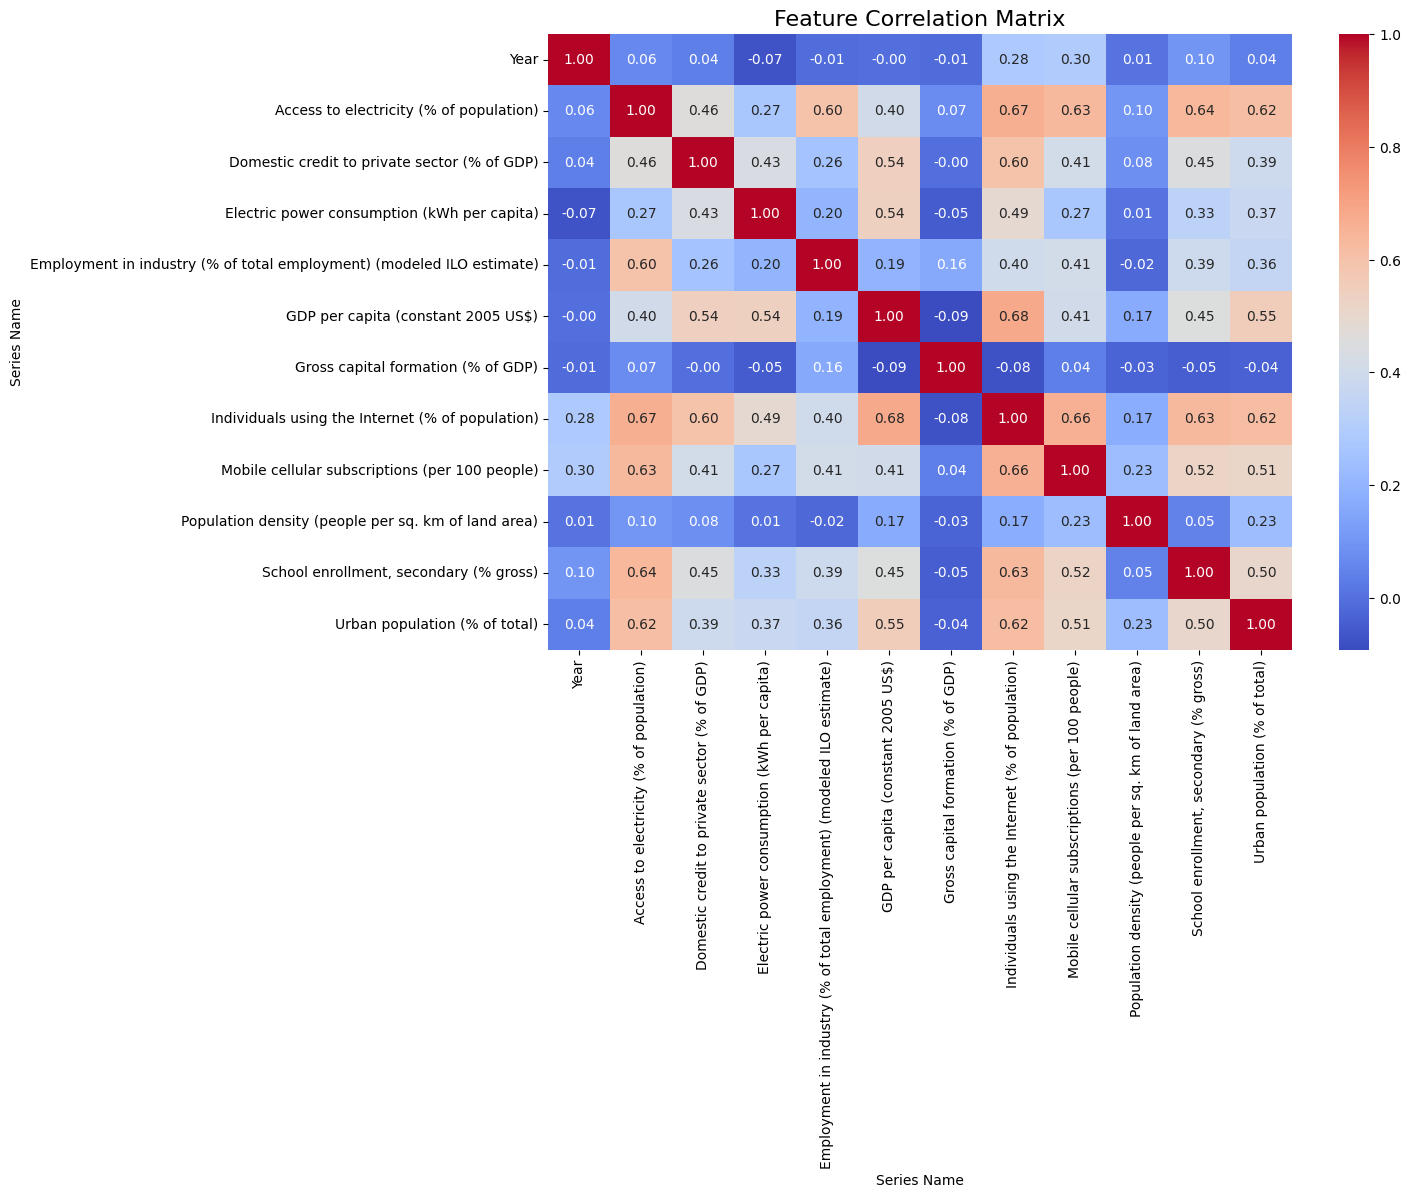

In [17]:
# ============================================
# CORRELATION MATRIX
# ============================================

numeric_df = ml_df.select_dtypes(
    include=["float64", "int64"]
)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=16
)

plt.show()

In [18]:
# ============================================
# CORRELATION WITH TARGET VARIABLE
# ============================================

target_name = "Access to electricity (% of population)"

target_corr = (
    corr_matrix[target_name]
    .sort_values(ascending=False)
)

print(target_corr)

Series Name
Access to electricity (% of population)                                  1.000000
Individuals using the Internet (% of population)                         0.666794
School enrollment, secondary (% gross)                                   0.636402
Mobile cellular subscriptions (per 100 people)                           0.631830
Urban population (% of total)                                            0.615347
Employment in industry (% of total employment) (modeled ILO estimate)    0.596829
Domestic credit to private sector (% of GDP)                             0.461171
GDP per capita (constant 2005 US$)                                       0.403526
Electric power consumption (kWh per capita)                              0.270624
Population density (people per sq. km of land area)                      0.101156
Gross capital formation (% of GDP)                                       0.070901
Year                                                                     0.063087
Name

In [19]:
# ============================================
# CORRELATION WITHOUT TARGET VARIABLE
# ============================================
# Remove target itself from the list
target_corr_features = target_corr.drop(target_name)

print(target_corr_features)

Series Name
Individuals using the Internet (% of population)                         0.666794
School enrollment, secondary (% gross)                                   0.636402
Mobile cellular subscriptions (per 100 people)                           0.631830
Urban population (% of total)                                            0.615347
Employment in industry (% of total employment) (modeled ILO estimate)    0.596829
Domestic credit to private sector (% of GDP)                             0.461171
GDP per capita (constant 2005 US$)                                       0.403526
Electric power consumption (kWh per capita)                              0.270624
Population density (people per sq. km of land area)                      0.101156
Gross capital formation (% of GDP)                                       0.070901
Year                                                                     0.063087
Name: Access to electricity (% of population), dtype: float64


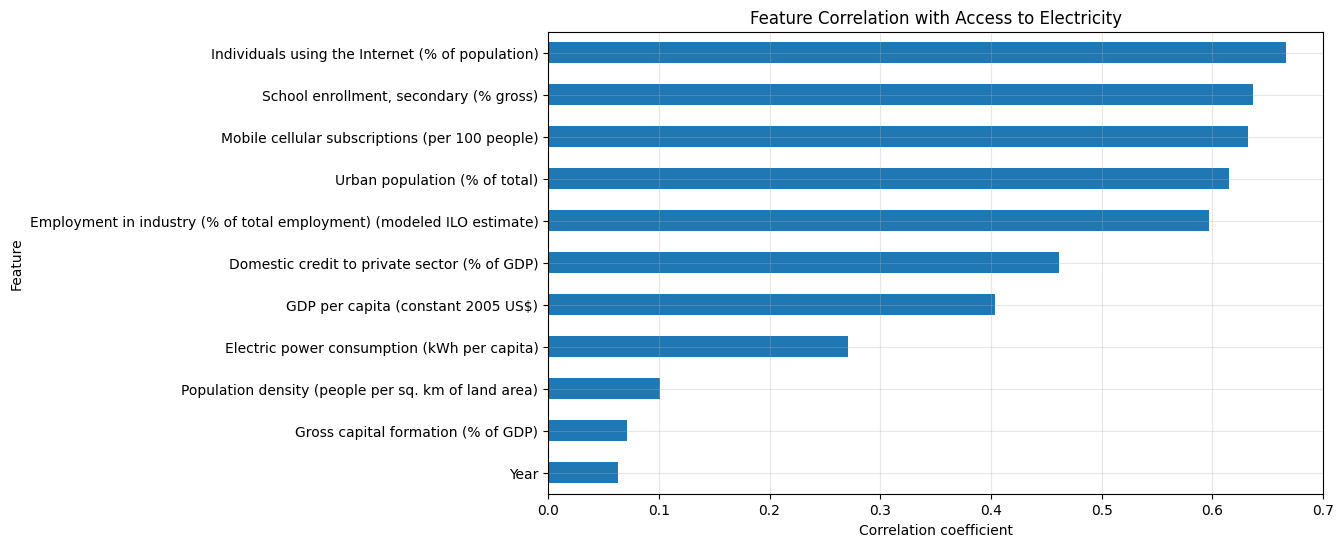

In [20]:
# ============================================
# VISUALIZE CORRELATION WITH TARGET
# ============================================

plt.figure(figsize=(10,6))

target_corr_features.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Access to Electricity")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")

plt.grid(alpha=0.3)
plt.show()

In [21]:
# ============================================
# SELECT STRONG FEATURES
# ============================================

strong_features = target_corr_features[
    abs(target_corr_features) >= 0.6
]

print(strong_features)

Series Name
Individuals using the Internet (% of population)    0.666794
School enrollment, secondary (% gross)              0.636402
Mobile cellular subscriptions (per 100 people)      0.631830
Urban population (% of total)                       0.615347
Name: Access to electricity (% of population), dtype: float64


# Correlation-Based Feature Selection

Features with an absolute correlation coefficient greater than or equal to 0.6 were selected for predictive modeling.

This approach helps identify variables with the strongest relationship to electricity access while reducing noise and redundant information.

In [22]:
# ============================================
# DEFINE FEATURES AND TARGET
# ============================================

target_name = "Access to electricity (% of population)"

selected_columns = [
    "Individuals using the Internet (% of population)",
    "School enrollment, secondary (% gross)",
    "Mobile cellular subscriptions (per 100 people)",
    "Urban population (% of total)"
]

# Features
X = ml_df[selected_columns]

# Target
y = ml_df[target_name]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (2420, 4)
y shape: (2420,)


Series Name,Individuals using the Internet (% of population),"School enrollment, secondary (% gross)",Mobile cellular subscriptions (per 100 people),Urban population (% of total)
0,1.90,29.368219,17.538162,23.113
1,1.84,39.286510,28.940060,23.320
2,3.55,45.645710,37.494200,23.528
3,4.00,51.981689,35.467766,23.737
4,5.00,53.249699,46.444058,23.948


In [23]:
# ============================================
# CHECK MISSING VALUES IN FEATURES
# ============================================

print(X.isnull().sum())


Series Name
Individuals using the Internet (% of population)    0
School enrollment, secondary (% gross)              0
Mobile cellular subscriptions (per 100 people)      0
Urban population (% of total)                       0
dtype: int64


In [24]:
# ============================================
# CHECK MISSING VALUES IN TARGET
# ============================================
print(y.isnull().sum())

0


# Train, Validation, and Test Split

The dataset was divided into three subsets:

- Training set (70%) used for model training
- Validation set (15%) used for model evaluation and tuning
- Test set (15%) used for final performance assessment

This approach helps reduce overfitting and ensures that the model generalizes well to unseen data.

In [25]:
# ============================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

# First split: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Second split: validation + test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1694, 4)
X_valid shape: (363, 4)
X_test shape: (363, 4)


# Random Forest Regressor

A Random Forest Regressor model was selected for predictive modeling.

This algorithm was chosen because:
- it handles nonlinear relationships effectively,
- it works well with tabular socioeconomic data,
- it is robust to outliers and missing values,
- and it provides feature importance analysis for model interpretability.

In [26]:
# ============================================
# RANDOM FOREST REGRESSOR
# ============================================

from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(
    X_train,
    y_train
)

print("Model trained successfully.")

Model trained successfully.


# Model Predictions

The trained Random Forest model was used to predict electricity access values for the validation dataset.

These predictions will be compared with the actual target values using multiple evaluation metrics.

In [27]:
# ============================================
# MAKE PREDICTIONS
# ============================================

# Predict values
y_pred = rf_model.predict(X_valid)

# Display first predictions
print(y_pred[:10])

[ 99.92622134 100.          39.25146628  99.99356988  99.99226319
  94.60335511  69.2555135   99.9300419   94.34582103  42.38035227]


# Model Evaluation

The Random Forest Regressor model was evaluated using three regression metrics:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

These metrics help measure prediction accuracy and model performance on unseen validation data.

In [28]:
# ============================================
# MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MAE
mae = mean_absolute_error(
    y_valid,
    y_pred
)

# RMSE
rmse = mean_squared_error(
    y_valid,
    y_pred
) ** 0.5

# R²
r2 = r2_score(
    y_valid,
    y_pred
)

# Print results
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 5.646851024668276
RMSE: 10.460091236940553
R² Score: 0.8738716464461425


# Model Evaluation Results

The Random Forest Regressor achieved strong predictive performance on the validation dataset.

## Evaluation Metrics

- MAE: 5.65
- RMSE: 10.46
- R² Score: 0.87

## Interpretation

The R² score of 0.87 indicates that the model explains approximately 87% of the variance in electricity access levels across countries.

The MAE value shows that the average prediction error is approximately 5.6 percentage points, which suggests that the model predictions are reasonably accurate.

The RMSE value is higher than the MAE, indicating that some predictions contain larger errors. However, the overall model performance remains strong for global socioeconomic data.

These results suggest that the selected features provide meaningful information for predicting electricity access levels.

# Final Test Evaluation

After validation, the trained Random Forest model was evaluated on the independent test dataset.

The test dataset represents unseen data and provides a more reliable estimate of the model's real-world predictive performance.

Comparing validation and test metrics helps identify potential overfitting and evaluates model generalization.

In [29]:
# ============================================
# TEST SET PREDICTIONS
# ============================================

# Predict on test dataset
y_test_pred = rf_model.predict(X_test)

print(y_test_pred[:10])

[99.96135969 96.37938587 93.07446559 48.36760571 99.99999999 99.99999995
 40.93123213 41.73781863 73.24706777 67.78328867]


In [30]:
# ============================================
# TEST SET EVALUATION
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MAE
test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

# RMSE
test_rmse = mean_squared_error(
    y_test,
    y_test_pred
) ** 0.5

# R²
test_r2 = r2_score(
    y_test,
    y_test_pred
)

# Print results
print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test MAE: 5.79876646969906
Test RMSE: 10.631303759177479
Test R²: 0.8625659712280647


# Final Model Performance

The Random Forest Regressor achieved consistent performance on both the validation and test datasets.

## Test Results

- MAE: 5.80
- RMSE: 10.63
- R² Score: 0.86

## Interpretation

The test R² score of 0.86 indicates that the model explains approximately 86% of the variance in electricity access levels across countries.

The similarity between validation and test results suggests that the model generalizes well and does not suffer from significant overfitting.

Overall, the selected socioeconomic and technological indicators provide strong predictive power for estimating electricity access levels.

# SHAP Analysis

SHAP values were used to explain the predictions of the Random Forest Regressor.

This method shows how each feature contributes to the model predictions and helps identify the most influential variables affecting electricity access.

The SHAP summary plot provides both feature importance and the direction of impact on the predicted electricity access level.

In [31]:
# ============================================
# SHAP IMPORT
# ============================================

# Uncomment this line if SHAP is not installed
#!pip install shap

import shap

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
# ============================================
# CREATE SHAP EXPLAINER
# ============================================

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

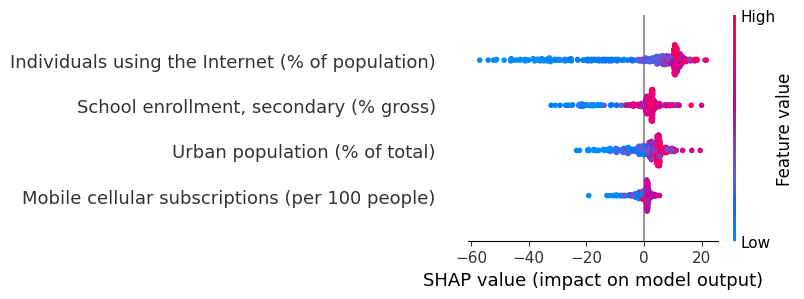

In [33]:
# ============================================
# SHAP SUMMARY PLOT
# ============================================

shap.summary_plot(
    shap_values,
    X_test
)

# SHAP Interpretation

The SHAP analysis identified the most influential features affecting electricity access predictions.

## Key Findings

- Internet usage was the most important predictor in the model.
- Secondary school enrollment also showed strong influence on electricity access.
- Urban population contributed positively to the predictions, suggesting that urbanized countries tend to have better electricity infrastructure.
- Mobile cellular subscriptions had a smaller but still measurable impact.

The SHAP summary plot demonstrates that technological development, education, and urbanization are strongly associated with electricity access levels across countries.

In [34]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                                            Feature  Importance
0  Individuals using the Internet (% of population)    0.671886
3                     Urban population (% of total)    0.146670
1            School enrollment, secondary (% gross)    0.124415
2    Mobile cellular subscriptions (per 100 people)    0.057029


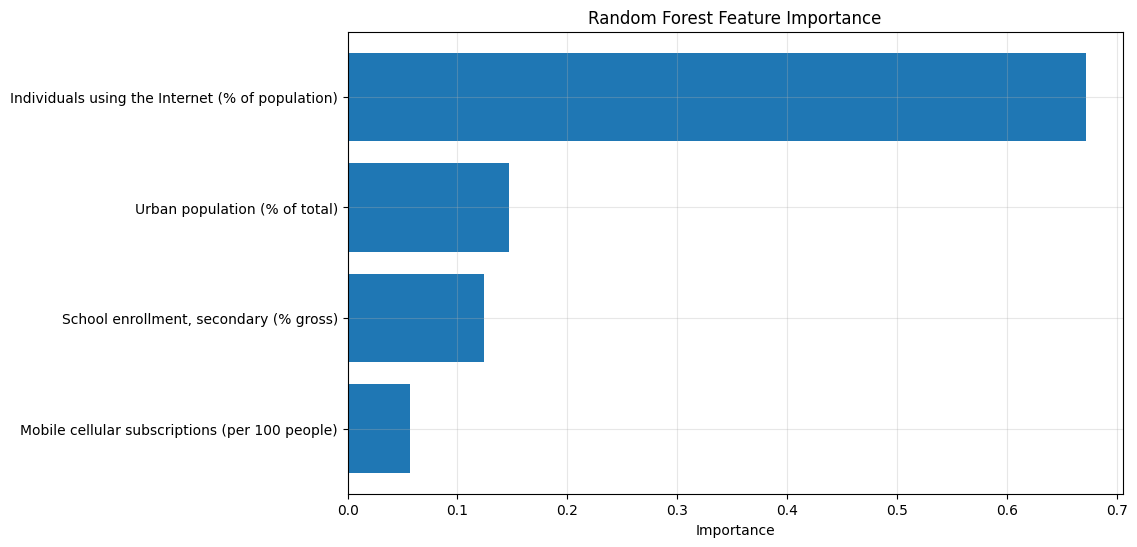

In [35]:
# ============================================
# FEATURE IMPORTANCE PLOT
# ============================================

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.grid(alpha=0.3)

plt.show()

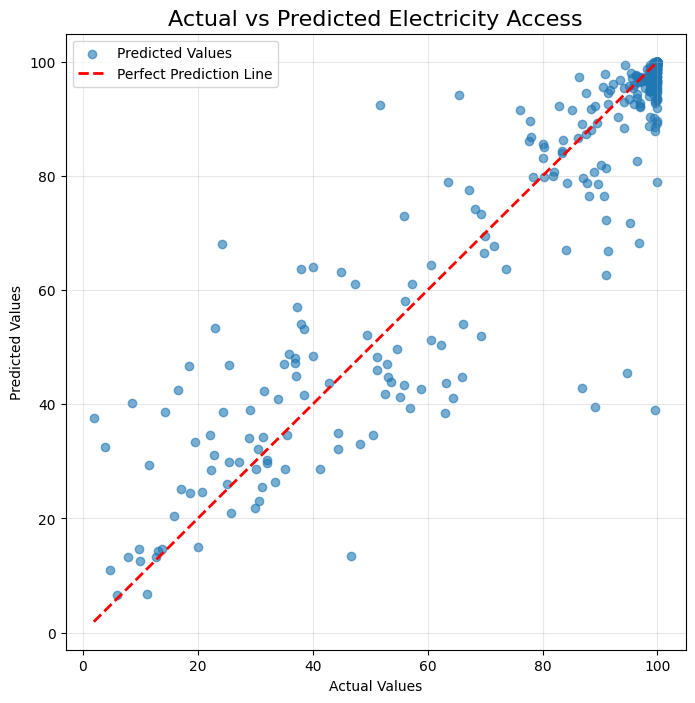

In [36]:
# ============================================
# ACTUAL VS PREDICTED
# ============================================

plt.figure(figsize=(8,8))

# Scatter plot
plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6,
    label="Predicted Values"
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Perfect Prediction Line"
)

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Title
plt.title(
    "Actual vs Predicted Electricity Access",
    fontsize=16
)

# Add legend
plt.legend(loc="upper left")

# Grid
plt.grid(alpha=0.3)

plt.show()

# Actual vs Predicted Analysis

The scatter plot compares actual electricity access values with the predictions generated by the Random Forest model.

Most data points are concentrated around the diagonal reference line, indicating that the model achieves strong predictive performance.

The model performs particularly well for countries with high electricity access levels. Greater variability can be observed for countries with medium electricity access values, suggesting more complex socioeconomic relationships in developing regions.

Several outliers are also present, which is expected in large global socioeconomic datasets.

In [37]:
# ============================================
# HYPERPARAMETER TUNING
# ============================================

from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Train grid search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best score
print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation R²:
0.8209673451017178


In [38]:
# ============================================
# BEST MODEL
# ============================================

best_rf_model = grid_search.best_estimator_

print(best_rf_model)

RandomForestRegressor(n_estimators=200, random_state=42)


In [39]:
# ============================================
# EVALUATE BEST MODEL
# ============================================

best_y_pred = best_rf_model.predict(X_test)

# Metrics
best_mae = mean_absolute_error(
    y_test,
    best_y_pred
)

best_rmse = mean_squared_error(
    y_test,
    best_y_pred
) ** 0.5

best_r2 = r2_score(
    y_test,
    best_y_pred
)

print("Tuned Model MAE:", best_mae)
print("Tuned Model RMSE:", best_rmse)
print("Tuned Model R²:", best_r2)

Tuned Model MAE: 5.820798376298202
Tuned Model RMSE: 10.639970386741053
Tuned Model R²: 0.8623418077470116


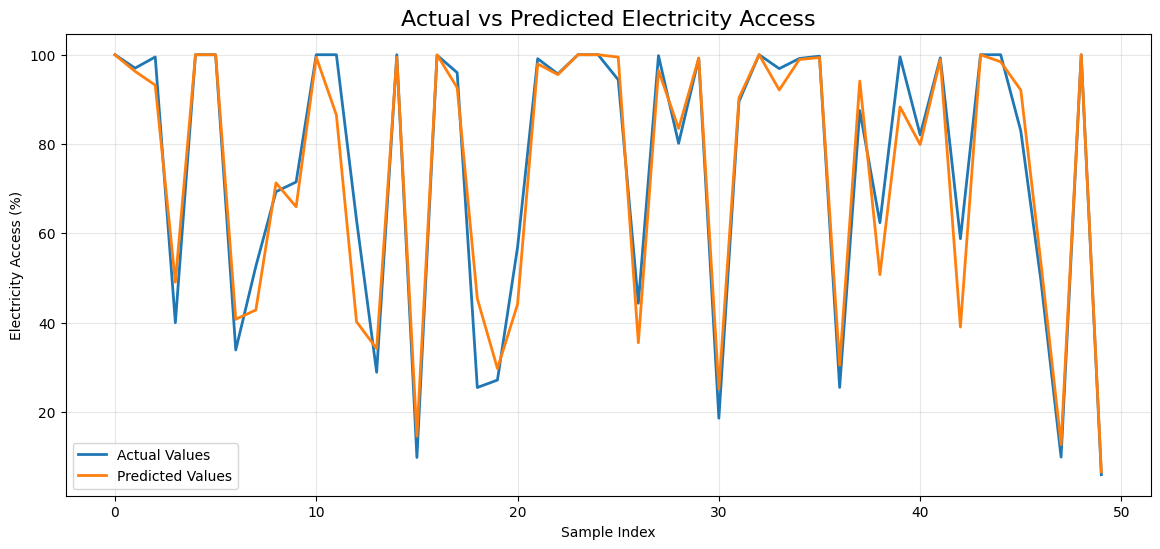

In [40]:
# ============================================
# PREDICTION COMPARISON
# ============================================

# Create figure
plt.figure(figsize=(14,6))

# Plot actual values
plt.plot(
    y_test.values[:50],
    label="Actual Values",
    linewidth=2
)

# Plot predicted values
plt.plot(
    best_y_pred[:50],
    label="Predicted Values",
    linewidth=2
)

# Title and labels
plt.title(
    "Actual vs Predicted Electricity Access",
    fontsize=16
)

plt.xlabel("Sample Index")
plt.ylabel("Electricity Access (%)")

# Legend
plt.legend()

# Grid
plt.grid(alpha=0.3)

plt.show()

# Prediction Comparison

The prediction comparison plot visualizes the relationship between actual and predicted electricity access values.

The close alignment between both curves indicates that the Random Forest model captures the overall patterns in the dataset effectively.

Some deviations are still present, particularly for more complex or less represented observations, which is expected in large-scale socioeconomic datasets.

# Forecasting Future Electricity Access

The trained machine learning model was used to forecast future electricity access levels for a selected country.

Future scenarios were generated by modifying socioeconomic indicators such as internet usage, education levels, urbanization, and mobile subscriptions.

In [41]:
# ============================================
# CLEAN FORECAST VISUALIZATION
# ============================================

# Choose country
country_name = "India"

country_data = ml_df[
    ml_df["Country Name"] == country_name
].sort_values("Year")

latest_data = country_data.iloc[-1]
last_year = int(country_data["Year"].max())

# Forecast next 5 years
future_years = list(range(last_year + 1, last_year + 6))

future_scenarios = []

for i, year in enumerate(future_years, start=1):
    future_scenarios.append({
        "Individuals using the Internet (% of population)": min(
            latest_data["Individuals using the Internet (% of population)"] + i * 3, 100
        ),
        "School enrollment, secondary (% gross)": min(
            latest_data["School enrollment, secondary (% gross)"] + i * 1, 100
        ),
        "Mobile cellular subscriptions (per 100 people)": (
            latest_data["Mobile cellular subscriptions (per 100 people)"] + i * 3
        ),
        "Urban population (% of total)": min(
            latest_data["Urban population (% of total)"] + i * 0.5, 100
        )
    })

future_scenarios = pd.DataFrame(future_scenarios)

future_predictions = best_rf_model.predict(future_scenarios)

forecast_df = pd.DataFrame({
    "Year": future_years,
    "Predicted Electricity Access": future_predictions
})

print(forecast_df)

   Year  Predicted Electricity Access
0  2017                     86.299105
1  2018                     90.917492
2  2019                     92.315335
3  2020                     96.334171
4  2021                     96.824431


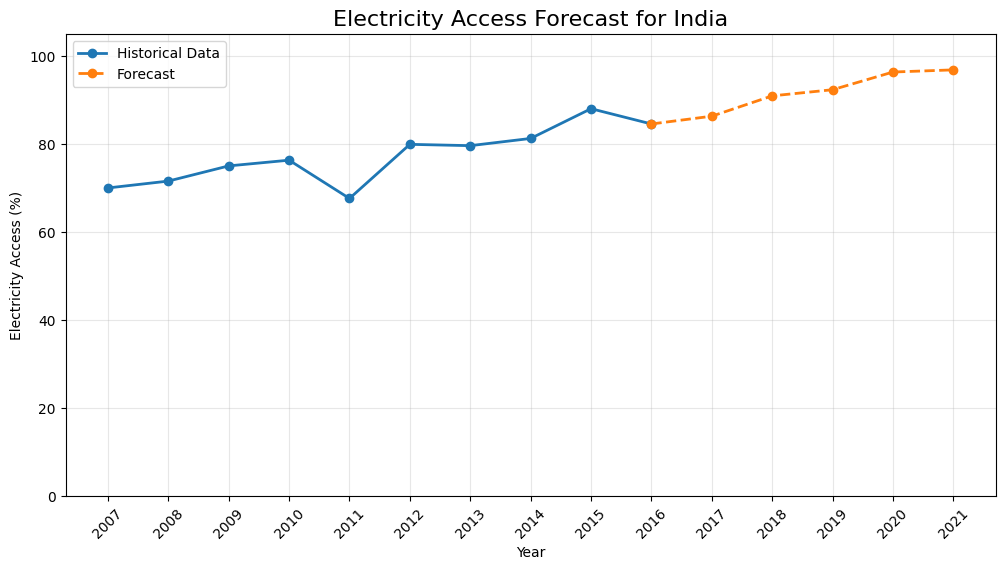

In [42]:
# ============================================
# CLEAN FORECAST PLOT - CONNECTED
# ============================================

plt.figure(figsize=(12,6))

# Historical data
plt.plot(
    country_data["Year"],
    country_data[target_name],
    marker="o",
    linewidth=2,
    label="Historical Data"
)

# Add last historical point to forecast line
forecast_years_connected = [country_data["Year"].iloc[-1]] + list(forecast_df["Year"])

forecast_values_connected = [country_data[target_name].iloc[-1]] + list(
    forecast_df["Predicted Electricity Access"]
)

# Forecast data
plt.plot(
    forecast_years_connected,
    forecast_values_connected,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

plt.title(f"Electricity Access Forecast for {country_name}", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Electricity Access (%)")

plt.xticks(
    list(country_data["Year"]) + list(forecast_df["Year"]),
    rotation=45
)

plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Final Conclusions

The project demonstrated how machine learning can be used to predict and forecast electricity access levels using global socioeconomic indicators.

The results showed that internet usage, education, and urbanization are strongly associated with electricity infrastructure development.

The Random Forest model achieved strong predictive performance and generalized well on unseen data.